# PCA Visualization of BrainIAC Features

This notebook loads a features CSV (rows = scans, columns = Feature_0...Feature_767 and a label column), performs PCA on the latent features, and visualizes results: scree plot, 2D/3D scatter of samples in PC space, and top contributing features per principal component.

How to use:
- Set the `csv_path` variable in the first code cell to point to your features CSV.
- Set `n_components` for PCA and `top_k` to show top contributing features.
- Run all cells.


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display
sns.set(style='whitegrid', context='notebook')


In [2]:
# Parameters
csv_path = 'features.csv'  # path to your features CSV
n_components = 10  # how many principal components to compute/plot
top_k = 10  # top contributing features to show for each principal component
sample_for_pairplot = 1000  # if dataset is large, sample this many rows for pairplot (None to use all)
show_3d = True  # whether to show 3D scatter if n_components >= 3
output_reduced_csv = 'features_pca.csv'  # optional: save the PCA-transformed data


In [3]:
# Load CSV and detect feature columns
df = pd.read_csv(csv_path)
print('Loaded', csv_path, 'with shape', df.shape)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]
print('Found feature columns:', len(feature_cols))
if not feature_cols:
    # fallback: assume all columns except last are features
    feature_cols = df.columns[:-1].tolist()
    print('Falling back to all columns except last as features. Using', len(feature_cols), 'features.')
# detect label column if present
non_feature_cols = [c for c in df.columns if c not in feature_cols]
label_col = None
if non_feature_cols:
    # if exactly one non-feature column, choose it; else look for 'GroundTruthClassLabel' or 'label'
    if len(non_feature_cols) == 1:
        label_col = non_feature_cols[0]
    else:
        for candidate in ['GroundTruthClassLabel', 'label', 'Label', 'class', 'Class']:
            if candidate in df.columns:
                label_col = candidate
                break
print('Using label column:', label_col)
X = df[feature_cols].values.astype(float)
print('Feature matrix shape:', X.shape)


Loaded features.csv with shape (13, 769)
Found feature columns: 768
Using label column: GroundTruthClassLabel
Feature matrix shape: (13, 768)


In [4]:
# Standardize and run PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
pc_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
if label_col:
    df_pca[label_col] = df[label_col].values
print('PCA done. Explained variance ratios:', pca.explained_variance_ratio_)


PCA done. Explained variance ratios: [0.44631153 0.19180494 0.1439665  0.05664573 0.04666493 0.03138104
 0.02479433 0.01733445 0.01625942 0.01105484]


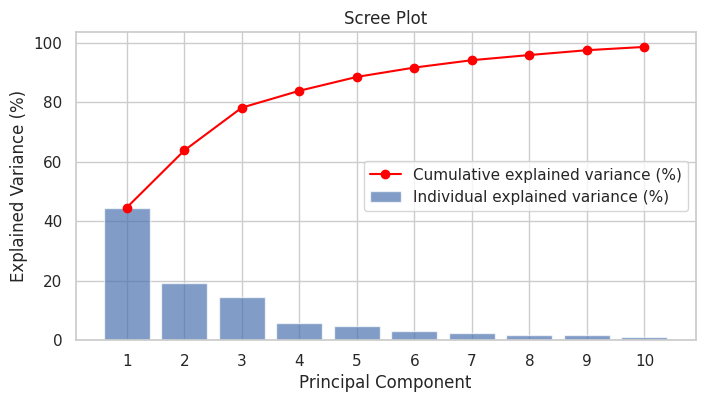

In [5]:
# Scree plot
var_ratio = pca.explained_variance_ratio_
cumvar = np.cumsum(var_ratio)
plt.figure(figsize=(8,4))
plt.bar(range(1, len(var_ratio)+1), var_ratio*100, alpha=0.7, label='Individual explained variance (%)')
plt.plot(range(1, len(var_ratio)+1), cumvar*100, marker='o', color='red', label='Cumulative explained variance (%)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(var_ratio)+1))
plt.legend()
plt.grid(True)
plt.show()


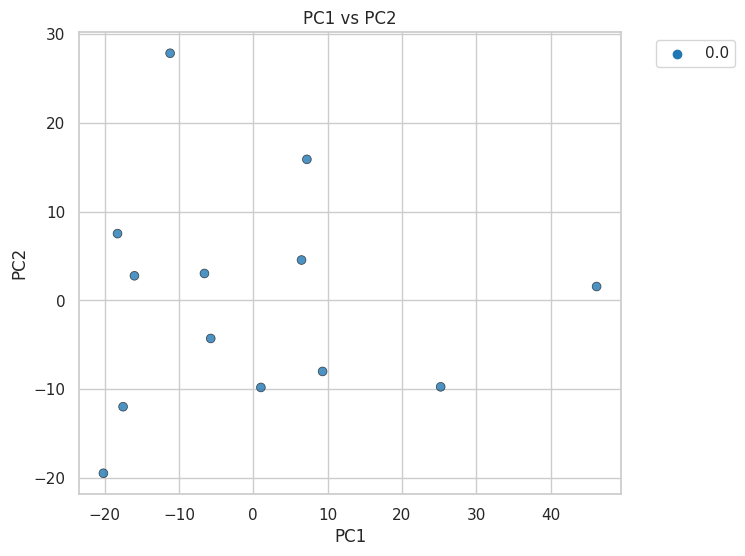

In [6]:
# 2D scatter of first two PCs
plt.figure(figsize=(7,6))
if label_col:
    labels = df_pca[label_col]
    # if labels numeric with many unique values, use colorbar
    unique_labels = np.unique(labels)
    if len(unique_labels) <= 20:
        sns.scatterplot(x='PC1', y='PC2', hue=label_col, data=df_pca, palette='tab10', s=40, edgecolor='k', alpha=0.8)
        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    else:
        plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels, cmap='viridis', s=30, alpha=0.8)
        plt.colorbar(label=label_col)
else:
    plt.scatter(df_pca['PC1'], df_pca['PC2'], s=30, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')
plt.grid(True)
plt.show()


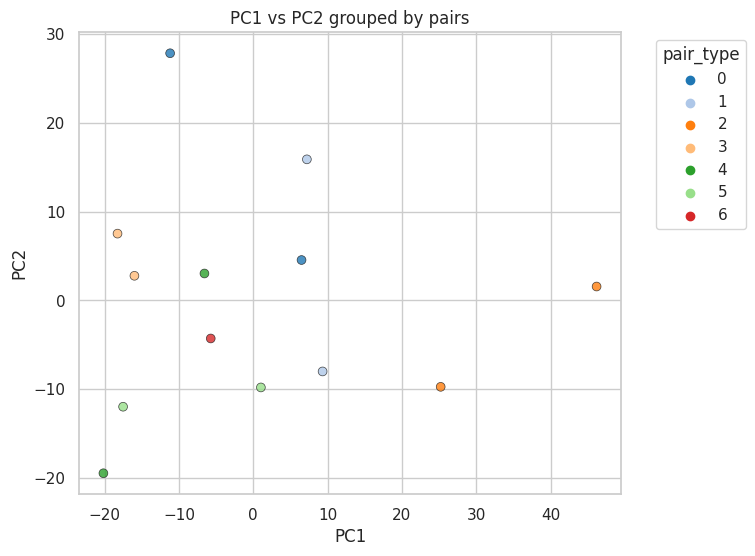

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create pair-based labels: [0,1] -> 0, [2,3] -> 1, [4,5] -> 2, ...
df_pca = df_pca.copy()
df_pca['pair_type'] = np.arange(len(df_pca)) // 2

# 2D scatter of first two PCs
plt.figure(figsize=(7,6))

unique_labels = np.unique(df_pca['pair_type'])

if len(unique_labels) <= 20:
    sns.scatterplot(
        x='PC1', y='PC2',
        hue='pair_type',
        data=df_pca,
        palette='tab20',
        s=40,
        edgecolor='k',
        alpha=0.8
    )
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='pair_type')
else:
    plt.scatter(
        df_pca['PC1'], df_pca['PC2'],
        c=df_pca['pair_type'],
        cmap='viridis',
        s=30,
        alpha=0.8
    )
    plt.colorbar(label='pair_type')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 grouped by pairs')
plt.grid(True)
plt.show()

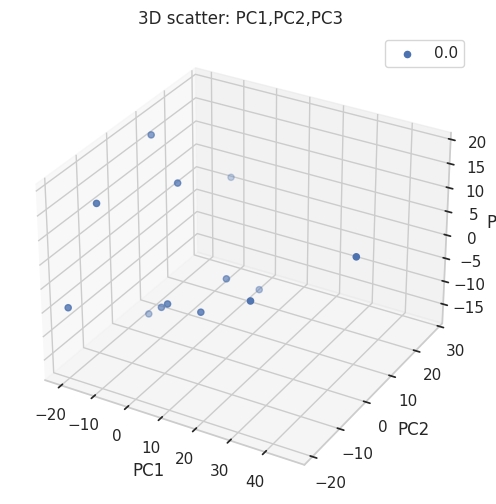

In [8]:
# 3D scatter of first three PCs (if available)
if show_3d and X_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    if label_col:
        labels = df_pca[label_col]
        unique_labels = np.unique(labels)
        if len(unique_labels) <= 20:
            for lab in unique_labels:
                mask = labels == lab
                ax.scatter(df_pca.loc[mask,'PC1'], df_pca.loc[mask,'PC2'], df_pca.loc[mask,'PC3'], label=str(lab), s=20)
            ax.legend()
        else:
            sc = ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], c=labels, cmap='viridis', s=20)
            fig.colorbar(sc, ax=ax, label=label_col)
    else:
        ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'], s=20)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title('3D scatter: PC1,PC2,PC3')
    plt.show()
else:
    print('3D scatter not shown (need n_components >= 3 and show_3d=True).')


In [9]:
import numpy as np
import pandas as pd
import plotly.express as px

# Create pair-based labels: [0,1] -> 0, [2,3] -> 1, [4,5] -> 2, ...
df_pca = df_pca.copy()
df_pca['pair_type'] = np.arange(len(df_pca)) // 2

# Check that PC3 exists
if 'PC3' not in df_pca.columns:
    raise ValueError("PC3 not found. Make sure PCA was run with at least 3 components.")

# Interactive 3D scatter plot
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='pair_type',
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=6))
fig.show()


Top 10 features for PC1:


,feature,loading
0,Feature_528,0.053095
1,Feature_648,-0.053089
2,Feature_104,0.052992
3,Feature_350,0.052823
4,Feature_279,-0.052809
5,Feature_491,0.052798
6,Feature_437,0.052709
7,Feature_751,-0.052680
8,Feature_593,0.052657
9,Feature_285,-0.052604


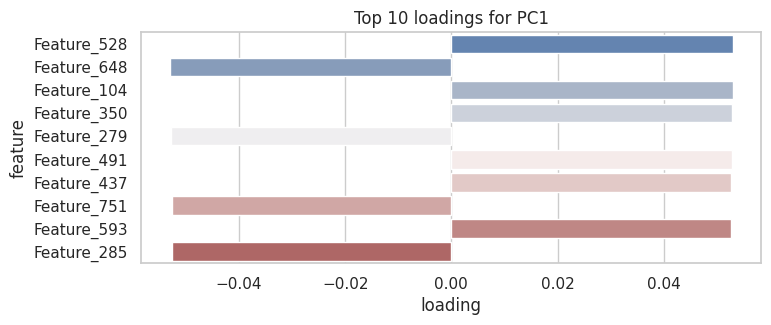


Top 10 features for PC2:


,feature,loading
0,Feature_208,0.079461
1,Feature_692,0.077649
2,Feature_57,0.077592
3,Feature_65,-0.076996
4,Feature_301,-0.076037
5,Feature_588,-0.075681
6,Feature_309,0.075137
7,Feature_11,-0.074973
8,Feature_353,0.074568
9,Feature_270,-0.074227


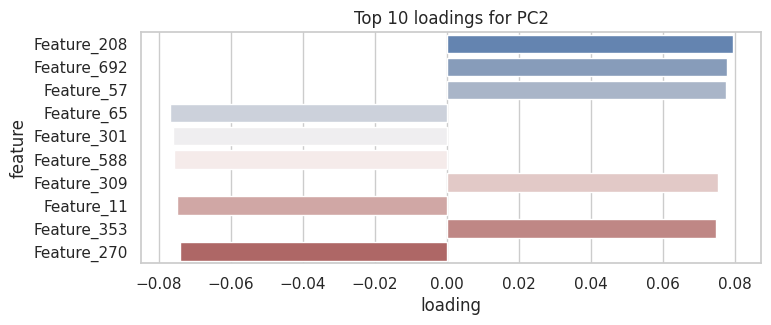


Top 10 features for PC3:


,feature,loading
0,Feature_553,-0.086235
1,Feature_566,0.085025
2,Feature_405,0.084217
3,Feature_78,-0.083485
4,Feature_73,0.081751
5,Feature_187,0.080742
6,Feature_549,-0.080315
7,Feature_76,0.080277
8,Feature_485,0.079857
9,Feature_496,-0.079573


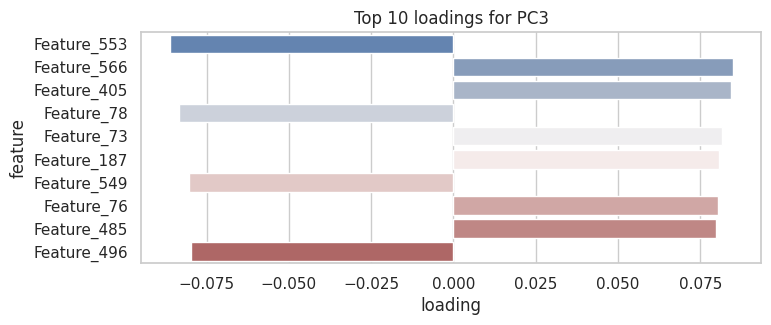


Top 10 features for PC4:


,feature,loading
0,Feature_338,-0.121188
1,Feature_478,-0.116700
2,Feature_492,0.111237
3,Feature_697,-0.105209
4,Feature_304,0.104495
5,Feature_407,0.103541
6,Feature_25,-0.102615
7,Feature_709,0.102509
8,Feature_677,-0.100386
9,Feature_62,-0.100321


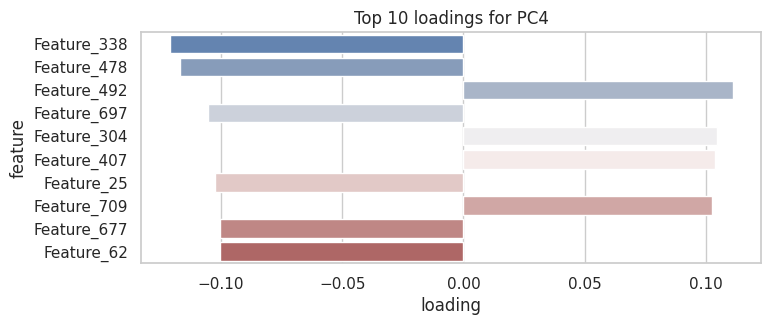


Top 10 features for PC5:


,feature,loading
0,Feature_657,0.147432
1,Feature_112,-0.133773
2,Feature_82,-0.126826
3,Feature_722,0.124393
4,Feature_106,-0.120278
5,Feature_221,-0.114106
6,Feature_406,-0.107985
7,Feature_292,-0.105247
8,Feature_33,-0.103468
9,Feature_303,-0.101729


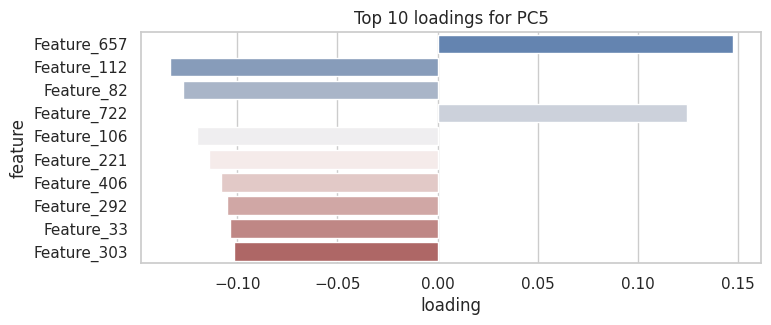


Top 10 features for PC6:


,feature,loading
0,Feature_543,-0.129438
1,Feature_316,-0.118039
2,Feature_151,-0.117632
3,Feature_355,0.113741
4,Feature_627,-0.113737
5,Feature_714,0.104635
6,Feature_502,0.103893
7,Feature_171,0.103576
8,Feature_465,-0.102265
9,Feature_296,0.102079


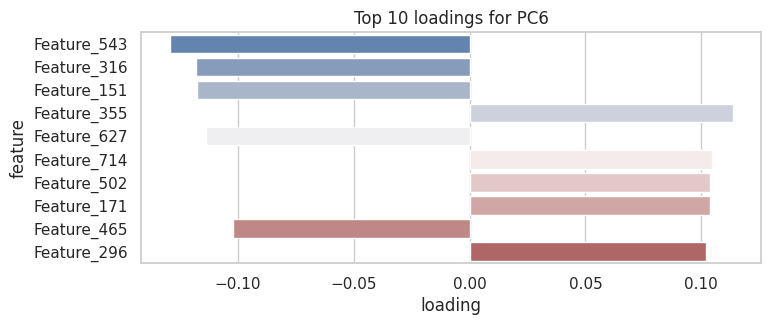


Top 10 features for PC7:


,feature,loading
0,Feature_468,-0.134093
1,Feature_444,0.118499
2,Feature_37,-0.116937
3,Feature_358,0.115597
4,Feature_685,-0.113641
5,Feature_63,-0.113406
6,Feature_641,0.111290
7,Feature_372,0.109969
8,Feature_336,-0.108711
9,Feature_22,0.106547


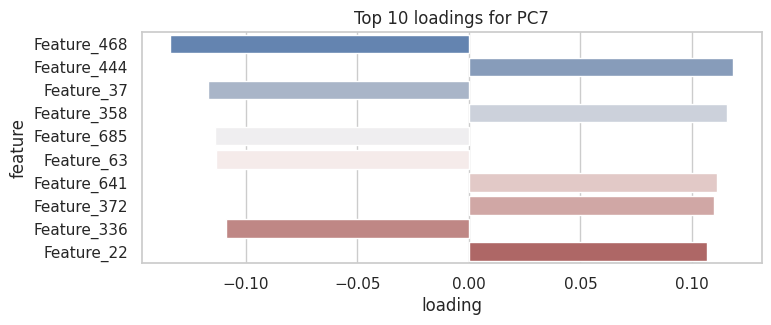


Top 10 features for PC8:


,feature,loading
0,Feature_490,-0.152726
1,Feature_543,-0.137644
2,Feature_581,-0.136952
3,Feature_77,-0.122150
4,Feature_62,0.111267
5,Feature_698,-0.111218
6,Feature_160,-0.108971
7,Feature_221,0.104711
8,Feature_151,0.102307
9,Feature_319,-0.094435


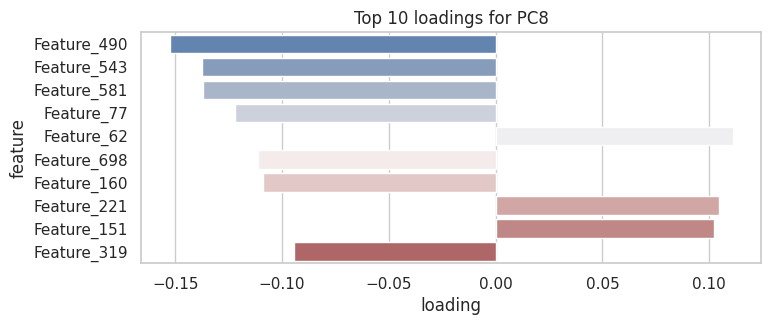


Top 10 features for PC9:


,feature,loading
0,Feature_338,-0.132207
1,Feature_637,0.127663
2,Feature_7,0.126072
3,Feature_304,0.118567
4,Feature_736,0.118020
5,Feature_444,0.114500
6,Feature_98,-0.110127
7,Feature_499,-0.110063
8,Feature_147,-0.101758
9,Feature_541,0.100237


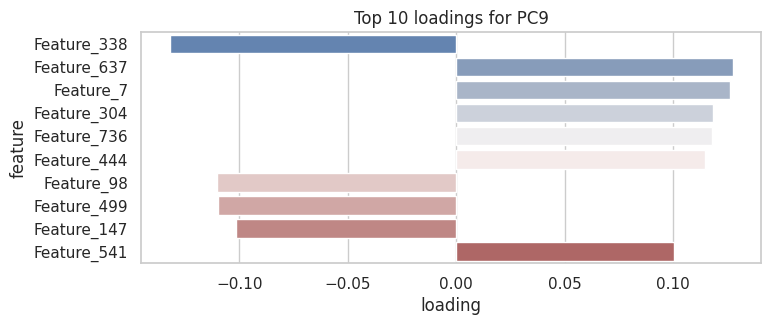


Top 10 features for PC10:


,feature,loading
0,Feature_82,-0.156899
1,Feature_180,-0.150838
2,Feature_401,-0.145175
3,Feature_233,0.137298
4,Feature_452,-0.127011
5,Feature_290,0.111347
6,Feature_340,-0.108299
7,Feature_220,0.107137
8,Feature_134,0.104969
9,Feature_742,-0.104933


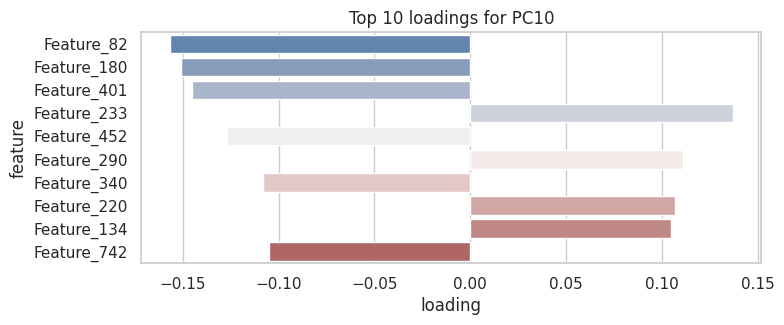

In [10]:
# Top contributing features per principal component
loadings = pca.components_  # shape (n_components, n_features)
abs_loadings = np.abs(loadings)
for i in range(loadings.shape[0]):
    comp = loadings[i]
    abs_comp = abs_loadings[i]
    top_idx = np.argsort(-abs_comp)[:top_k]
    top_features = [feature_cols[j] for j in top_idx]
    top_vals = comp[top_idx]
    df_load = pd.DataFrame({'feature': top_features, 'loading': top_vals})
    print(f"\nTop {top_k} features for PC{i+1}:")
    display(df_load)
    plt.figure(figsize=(8,3))
    sns.barplot(x='loading', y='feature', data=df_load, palette='vlag')
    plt.title(f'Top {top_k} loadings for PC{i+1}')
    plt.show()


/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/tydaniel-bybruce/miniconda3/envs/brainiac/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecate

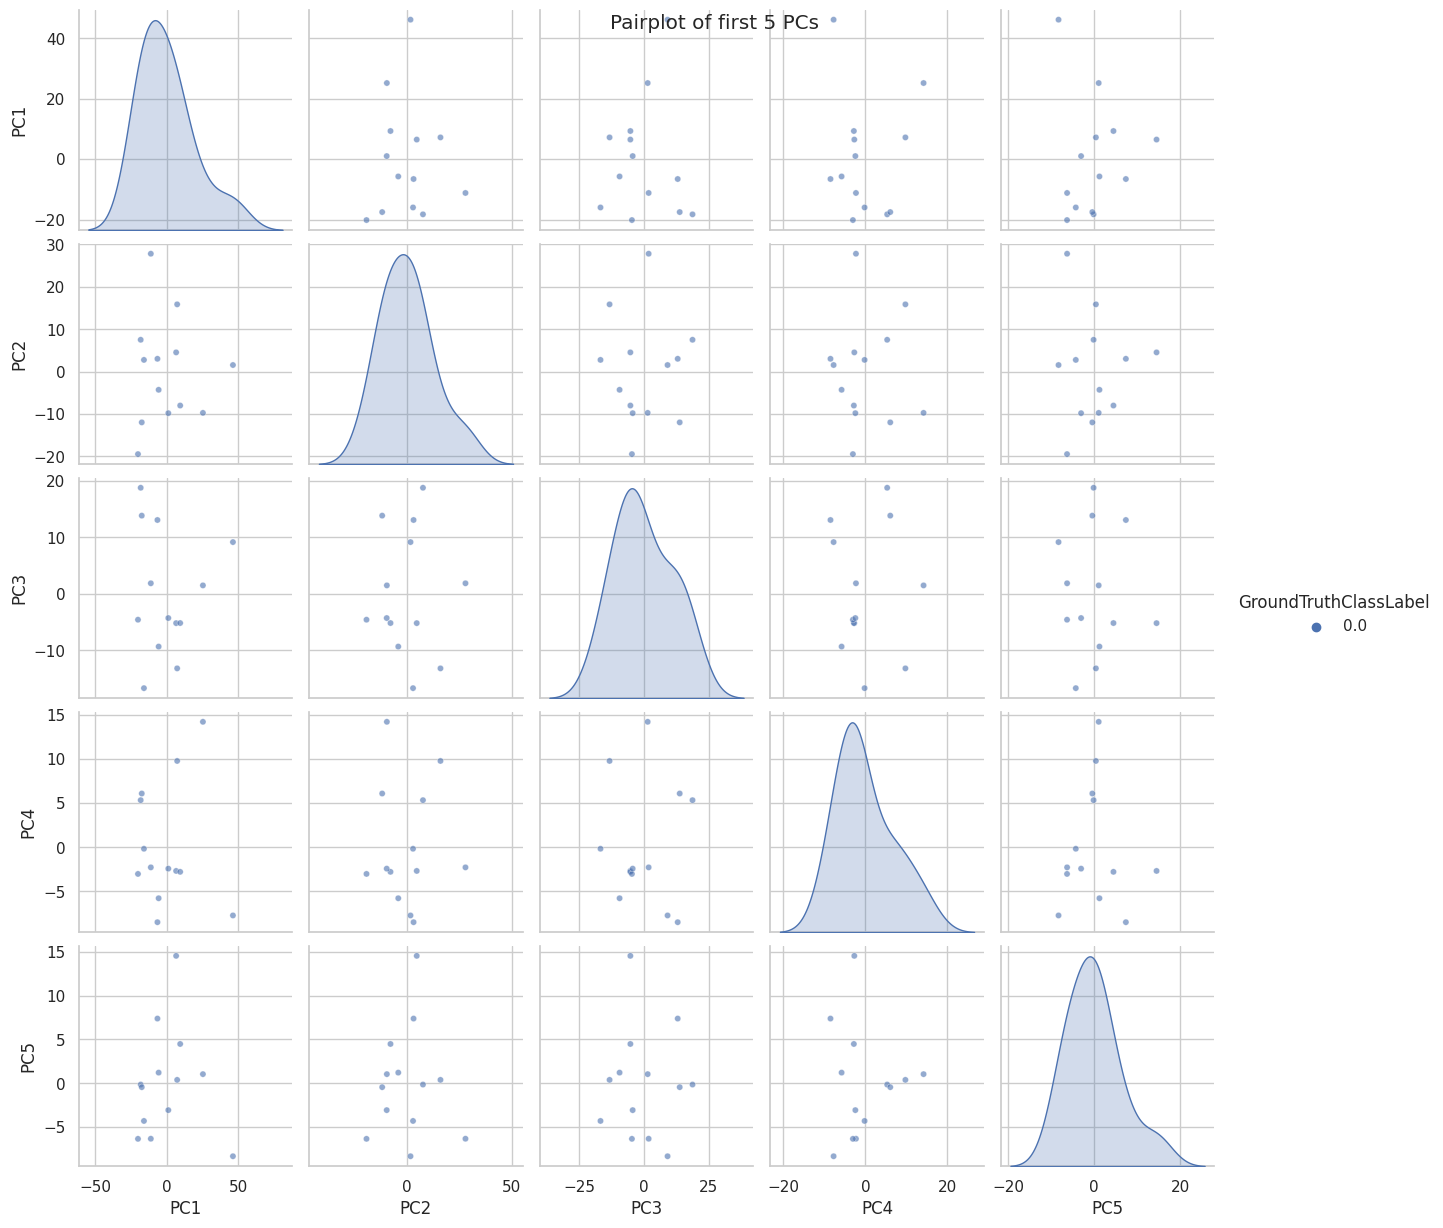

In [11]:
# Pairplot of first few PCs (sampled if large)
pc_for_pairplot = min(5, X_pca.shape[1])
vars_to_plot = [f'PC{i+1}' for i in range(pc_for_pairplot)]
df_pair = df_pca[vars_to_plot + ([label_col] if label_col else [])]
if sample_for_pairplot and len(df_pair) > sample_for_pairplot:
    df_pair_sample = df_pair.sample(sample_for_pairplot, random_state=42)
else:
    df_pair_sample = df_pair

if label_col:
    sns.pairplot(df_pair_sample, vars=vars_to_plot, hue=label_col, plot_kws={'s':20, 'alpha':0.6})
else:
    sns.pairplot(df_pair_sample, vars=vars_to_plot)
plt.suptitle('Pairplot of first %d PCs' % pc_for_pairplot)
plt.show()


In [12]:
# Optionally save PCA-transformed data
if output_reduced_csv:
    df_pca.to_csv(output_reduced_csv, index=False)
    print('Saved PCA-transformed data to', output_reduced_csv)


Saved PCA-transformed data to features_pca.csv
